In [30]:
#1번 문제

In [31]:
import pandas as pd

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

In [32]:
df = df[(df['Mixture']=='Chemical')&(df['Species']=='Human')&(df['Endpoint']=='Qualitative classification')]
df['label'] = (df['Response'].str.strip().str.lower()!='not classified').astype(int)

In [33]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)


In [34]:
df = df[(df['Mixture']=='Chemical')&(df['Species']=='Human')&(df['Endpoint']=='Qualitative classification')]
df['label'] = (df['Response'].str.strip().str.lower()!='not classified').astype(int)

#ㄱ
lfc = rdMolStandardize.LargestFragmentChooser()
df['smiles'] = df['SMILES'].apply(lambda s: Chem.MolToSmiles(lfc.choose(Chem.MolFromSmiles(s))) if isinstance(s,str) and Chem.MolFromSmiles(s) else None)
df = df[df['smiles'].notna()]

[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Fragment: *C
[12:29:39] New largest fragment: *C (5)
[12:29:39] Fragment: *C
[12:29:39] New largest fragment: *C (5)
[12:29:39] Fragment: OCCOCCO
[12:29:39] New largest fragment: OCCOCCO (17)
[12:29:39] Running LargestFragmentChooser
[12:29:39] Fragment: [OH-]
[12:29:39] New largest fragment: [OH-] (2)
[12:29:39] Fragment: [Na+]
[12:29:39] Running LargestFragmentChooser
[12:29:39] Fragment: [OH-]
[12:29:39] New largest fragment: [OH-] (2)
[12:29:39] Fragment: [Na+]
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running LargestFragmentChooser
[12:29:39] Fragment: [Na+]
[12:29:39] New largest fragmen

In [35]:
#ㄴ
u = rdMolStandardize.Uncharger()
df['smi'] = df['smiles'].apply(lambda s: Chem.MolToSmiles(u.uncharge(rdMolStandardize.FragmentParent(rdMolStandardize.Cleanup(Chem.MolFromSmiles(s))))) if Chem.MolFromSmiles(s) else None)
df = df[df['smi'].notna()]

#ㄷ
df = df[df.groupby('smi')['label'].transform('nunique')==1].drop_duplicates(['smi','label'])

#ㄹ
print(df['label'].value_counts())
print(df.shape)

label
0    45
1    11
Name: count, dtype: int64
(56, 28)


[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Normalizer
[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Normalizer
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running Uncharger
[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Normalizer
[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Normalizer
[12:29:39] Running LargestFragmentChooser
[12:29:39] Running Uncharger
[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Normalizer
[12:29:39] Initializing MetalDisconnector
[12:29:39] Running MetalDisconnector
[12:29:39] Initializing Normalizer
[12:29:39] Running Norma

In [36]:
from rdkit.Chem import Descriptors
from sklearn.linear_model import LogisticRegression

In [37]:
#ㄱ
X = pd.DataFrame([Descriptors.CalcMolDescriptors(Chem.MolFromSmiles(s)) for s in df['smi']])
y = df['label'].reset_index(drop=True)
X = X.loc[:, X.notna().all() & (X.nunique() > 1)]

In [38]:
#ㄴ
scores = {c: LogisticRegression(max_iter=1000).fit(X[[c]], y).score(X[[c]], y) for c in X.columns}

In [39]:
#ㄷ
best = max(scores, key=scores.get)
print(best, scores[best])

SlogP_VSA4 0.8392857142857143


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# feature, label
X_best = X[['SlogP_VSA4']]
y = df['label']

# 모델 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_best, y)

# 예측
y_pred = model.predict(X_best)

# 정확도
acc = model.score(X_best, y)
print("Accuracy:", acc)

# confusion matrix
cm = confusion_matrix(y, y_pred)
print(cm)

Accuracy: 0.8392857142857143
[[45  0]
 [ 9  2]]


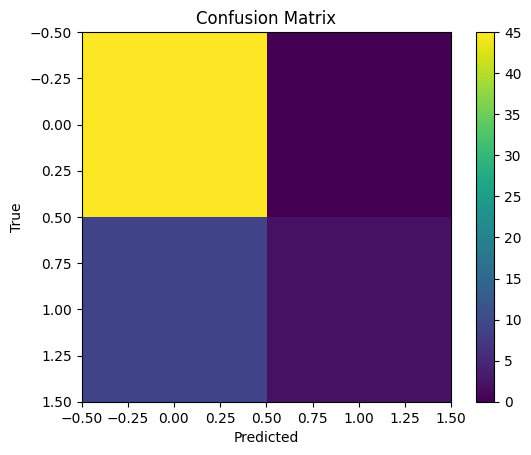

In [41]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

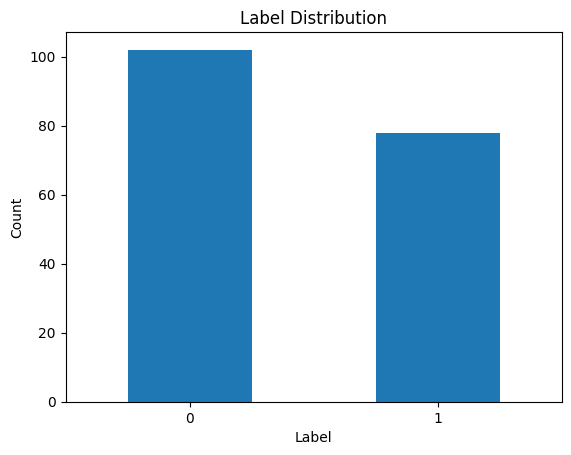

In [43]:
# 1) Label distribution
# skin_irritation_binary_dataset.csv에서 label 0, 1 개수 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('skin_irritation_binary_dataset.csv')

df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()